## Кодирование категориальных признаков

In [ ]:
# Создаем копию данных для кодирования
data_encoded = data.copy()

# 1. One-Hot Encoding для категориальных признаков без порядка
ohe_columns = ['tvCompanyName', 'programTypeName', 'programCategoryName']
data_encoded = pd.get_dummies(data_encoded, columns=ohe_columns, prefix=ohe_columns, drop_first=True) #сбрасывание одного из бинарных столбцов для линейной регрессии

# 2. Порядковое кодирование для возрастных рейтингов
# Создаем маппинг для преобразования в целые числа
age_mapping = {
    '0+': 0,
    '3+': 1,  # если нужно сохранить эти редкие категории
    '4+': 1,   # можно объединить с 3+
    '5+': 1,   # можно объединить с 6+
    '6+': 1,
    '12+': 2,
    '14+': 3,  # можно отнести к 16+
    '16+': 3,
    '18+': 4,
    '21+': 4   # можно отнести к 18+
}
# Применяем преобразование
data_encoded['programAgeRestrictionName'] = data_encoded['programAgeRestrictionName'].map(age_mapping).astype(int)

# 3. Бинарное кодирование для прайм-тайма
prime_time_encoder = LabelEncoder()
data_encoded['breaksPrimeTimeStatusName'] = prime_time_encoder.fit_transform(
    data_encoded['breaksPrimeTimeStatusName']
)

# 4. Порядковое кодирование для типов дней
day_type_order = ['W', 'E', 'H']  # Рабочий -> Выходной -> Праздник
day_type_mapping = {v: i for i, v in enumerate(day_type_order)}
data_encoded['researchDayType'] = data_encoded['researchDayType'].map(day_type_mapping)


In [ ]:
# Проверка результатов
print("=== One-Hot Encoded Columns ===")
for col in ohe_columns:
    new_cols = [c for c in data_encoded.columns if c.startswith(col+'_')]
    print(f"{col} -> {new_cols[:3]}...")  # Показываем первые 3 для краткости

print("\n=== Label Encoded Columns ===")
print("programAgeRestrictionName:", age_mapping)
print("breaksPrimeTimeStatusName:", dict(zip(prime_time_encoder.classes_, [0, 1])))
print("researchDayType:", day_type_mapping)

=== One-Hot Encoded Columns ===
tvCompanyName -> ['tvCompanyName_Звезда', 'tvCompanyName_Мир', 'tvCompanyName_НТВ']...
programTypeName -> ['programTypeName_Детская программа', 'programTypeName_Документальная программа', 'programTypeName_Кинофильм']...
programCategoryName -> ['programCategoryName_Детская передача', 'programCategoryName_Дневник спортивных событий', 'programCategoryName_Документальный сериал']...

=== Label Encoded Columns ===
programAgeRestrictionName: {'0+': 0, '3+': 1, '4+': 1, '5+': 1, '6+': 1, '12+': 2, '14+': 3, '16+': 3, '18+': 4, '21+': 4}
breaksPrimeTimeStatusName: {'Вне прайм-тайм': 0, 'Прайм-тайм': 1}
researchDayType: {'W': 0, 'E': 1, 'H': 2}


programName имеет более 15к уникальных значений, поэтому ичспользуем частоное кодирование

In [ ]:
# Частота встречаемости названий программ
program_freq = data_encoded['programName'].value_counts(normalize=True)
data_encoded['programName_freq'] = data_encoded['programName'].map(program_freq)

# Удаляем исходный столбец
data_encoded.drop('programName', axis=1, inplace=True)

Конвертируем время в минуты с начла дня

In [ ]:
def time_to_minutes(time_str):
    h, m, s = map(int, time_str.split(':'))
    return h * 60 + m + s / 60

for col in ['breaksStartTime', 'breaksFinishTime', 'programStartTime', 'programFinishTime']:
    data_encoded[col + '_min'] = data_encoded[col].apply(time_to_minutes)
    data_encoded.drop(col, axis=1, inplace=True)

In [ ]:
data_encoded.head()

,researchDate,researchDayType,tvCompanyId,breaksSpotId,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programDuration,SalesRtgPer,predictions,hour,minute,second,day,month,year,tvCompanyName_Звезда,tvCompanyName_Мир,tvCompanyName_НТВ,tvCompanyName_Первый,tvCompanyName_РЕН ТВ,tvCompanyName_Россия 1,tvCompanyName_Россия 24,tvCompanyName_СТС,tvCompanyName_ТВ Центр,tvCompanyName_ТВ3,tvCompanyName_ТНТ,tvCompanyName_ТНТ4,tvCompanyName_Че,programTypeName_Детская программа,programTypeName_Документальная программа,programTypeName_Кинофильм,programTypeName_Музыкальная программа,programTypeName_Новости,programTypeName_Познавательная программа,programTypeName_Прочее,programTypeName_Развлекательная программа,programTypeName_Социально-политическая программа,programTypeName_Спортивная программа,programTypeName_Телесериал,programCategoryName_Детская передача,programCategoryName_Дневник спортивных событий,programCategoryName_Документальный сериал,programCategoryName_Документальный фильм,programCategoryName_Другая информационная передача,programCategoryName_Другая музыкально-танцевальная передача,programCategoryName_Другая познавательная передача,programCategoryName_Другая развлекательная передача,programCategoryName_Другая социально-политическая передача,...,programCategoryName_Ежедневные новости,"programCategoryName_Женская передача, кулинарное шоу",programCategoryName_Закон и право,"programCategoryName_Игра-викторина, соревнование",programCategoryName_Информационно-аналитическая передача (комментарии),programCategoryName_Кинофильм,"programCategoryName_Классическая музыка, балет, опера",programCategoryName_Криминальные хроники,programCategoryName_Музыкально-развлекательная передача,programCategoryName_Мультипликационный сериал,programCategoryName_Мультипликационный фильм,programCategoryName_Народная музыка и танцы,programCategoryName_Научно-популярная передача,programCategoryName_Новости культуры,"programCategoryName_Передача о животных, растениях",programCategoryName_Передача о здоровье,programCategoryName_Передача о моде и дизайне,programCategoryName_Передача о спорте и спортсменах,programCategoryName_Передача об автомобилях,"programCategoryName_Передача об искусстве, культуре, истории",programCategoryName_Передача-диалог в прямом эфире,programCategoryName_Передача-интервью,programCategoryName_Поздравление,programCategoryName_Политическая передача,programCategoryName_Прогноз погоды,programCategoryName_Развлекательное ток-шоу,programCategoryName_Реалити-шоу,programCategoryName_Религиозная передача,"programCategoryName_Репортаж, трансляция","programCategoryName_Смешанный концерт, шоу, цирк",programCategoryName_Советы потребителю и реклама,"programCategoryName_Современная музыка, эстрадный концерт",programCategoryName_Социально-политическое ток-шоу,programCategoryName_Социально-публицистическая передача,"programCategoryName_Спектакль, литературное чтение",programCategoryName_Спортивные новости,programCategoryName_Спортивный журнал и аналитика,programCategoryName_Стиль жизни и досуг,programCategoryName_Телемагазин,programCategoryName_Телесериал,programCategoryName_Трансляция спортивного мероприятия,programCategoryName_Утренний эфир,programCategoryName_Хроники (кроме криминальных),programCategoryName_Экономика и бизнес,programCategoryName_Юмористическая передача,programName_freq,breaksStartTime_min,breaksFinishTime_min,programStartTime_min,programFinishTime_min
0,2020-01-01,2,1877,3676250151,205,1,2007-09-03 00:00:00,3,3285,1.367364,0.0,0,13,56,1,1,2020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,Fa

Визуализация данных


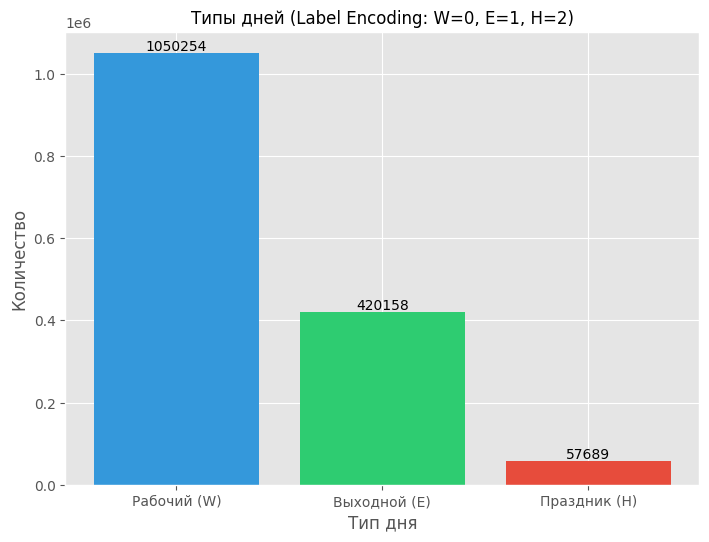

In [ ]:

plt.style.use('ggplot')
plt.figure(figsize=(18, 20))

# 1. Распределение типов дней (Label Encoded)
plt.subplot(3, 2, 1)
day_counts = data_encoded['researchDayType'].value_counts().sort_index()
bars = plt.bar(['Рабочий (W)', 'Выходной (E)', 'Праздник (H)'], day_counts,
               color=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Типы дней (Label Encoding: W=0, E=1, H=2)', fontsize=12)
plt.xlabel('Тип дня')
plt.ylabel('Количество')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

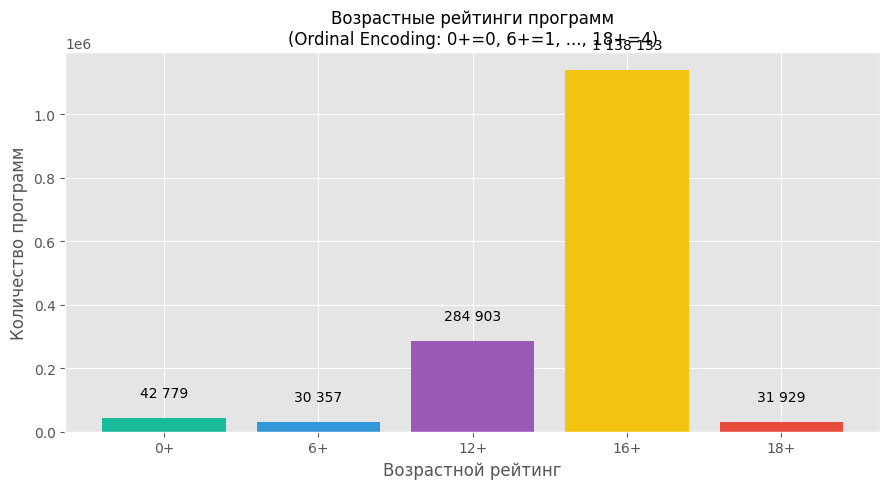

In [ ]:
# 2. Возрастные рейтинги (Ordinal Encoded)
plt.figure(figsize=(9, 5))
age_order = ['0+', '6+', '12+', '16+', '18+']

# Улучшение 1: Явное преобразование в int и сортировка по нашему порядку
age_counts = (data_encoded['programAgeRestrictionName']
              .value_counts()
              .loc[range(len(age_order))]  # Сортируем по закодированным значениям
              .astype(int))

# Улучшение 2: Добавляем отступ для подписей
label_offset = max(age_counts) * 0.05  # 5% от максимального значения

plt.bar(age_order, age_counts, color=['#1abc9c', '#3498db', '#9b59b6', '#f1c40f', '#e74c3c'])
plt.title('Возрастные рейтинги программ\n(Ordinal Encoding: 0+=0, 6+=1, ..., 18+=4)', fontsize=12)
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Количество программ')

# Улучшение 3: Более читаемые подписи значений
for i, v in enumerate(age_counts):
    plt.text(i, v + label_offset, f'{v:,}'.replace(',', ' '),  # Форматирование с пробелами
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Улучшение 4: Автоматическая подгонка отступов

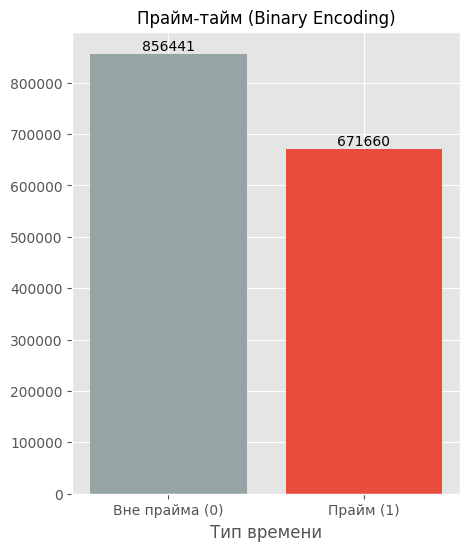

In [ ]:
# 3. Прайм-тайм (Binary Encoded)
plt.figure(figsize=(5, 6))
prime_counts = data_encoded['breaksPrimeTimeStatusName'].value_counts().sort_index()
bars = plt.bar(['Вне прайма (0)', 'Прайм (1)'], prime_counts,
               color=['#95a5a6', '#e74c3c'])
plt.title('Прайм-тайм (Binary Encoding)', fontsize=12)
plt.xlabel('Тип времени')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

Text(0.5, 0, 'Количество')

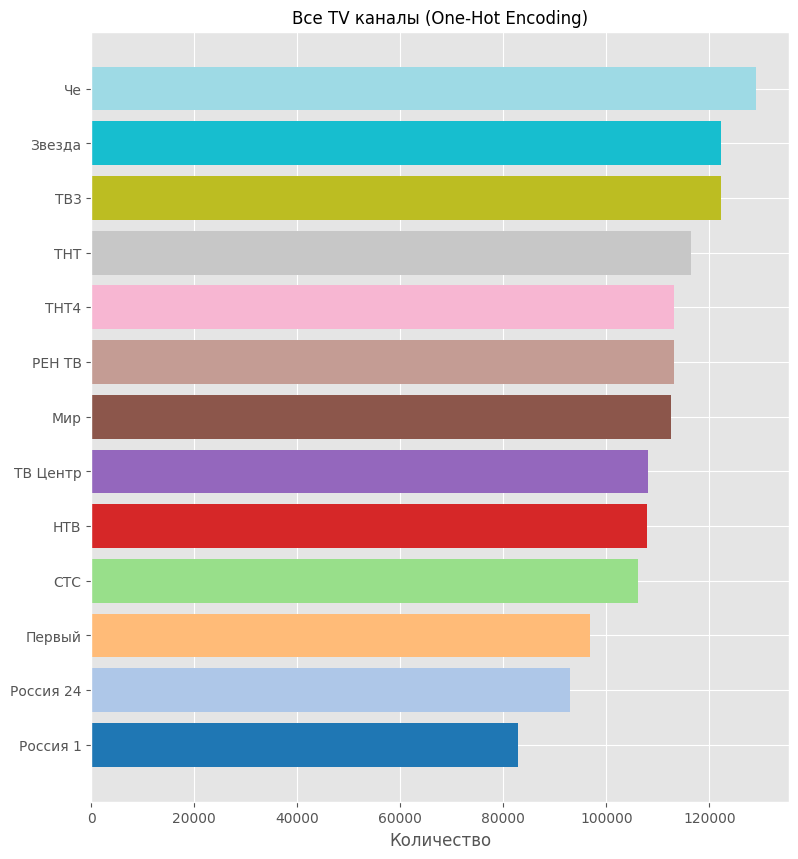

In [ ]:
# 4. Все TV каналы (One-Hot)
plt.figure(figsize=(9, 10))
tv_cols = [col for col in data_encoded.columns if 'tvCompanyName_' in col]
tv_counts = data_encoded[tv_cols].sum().sort_values()
plt.barh([x.replace('tvCompanyName_', '') for x in tv_counts.index], tv_counts,
         color=plt.cm.tab20(np.linspace(0, 1, len(tv_counts))))
plt.title('Все TV каналы (One-Hot Encoding)', fontsize=12)
plt.xlabel('Количество')

Text(0.5, 0, 'Количество')

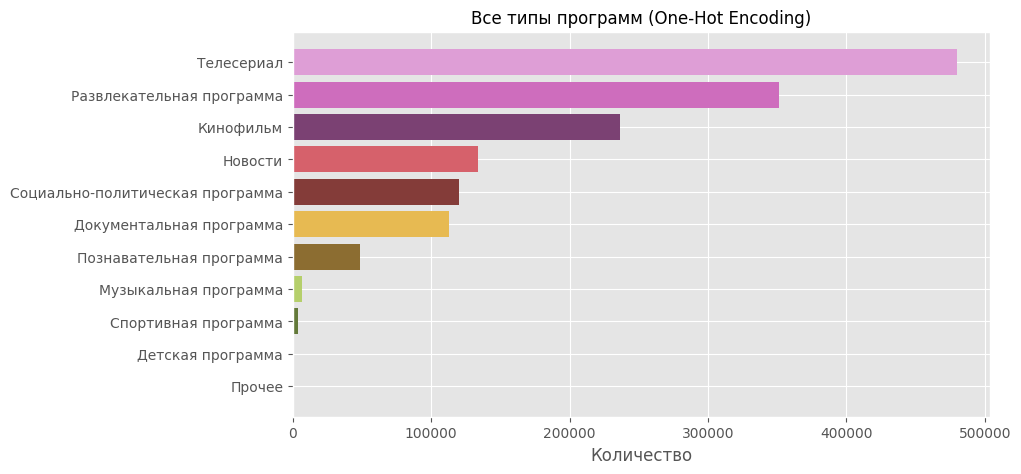

In [ ]:
# 5. Все типы программ (One-Hot)
plt.figure(figsize=(9, 5))
type_cols = [col for col in data_encoded.columns if 'programTypeName_' in col]
type_counts = data_encoded[type_cols].sum().sort_values()
plt.barh([x.replace('programTypeName_', '') for x in type_counts.index], type_counts,
         color=plt.cm.tab20b(np.linspace(0, 1, len(type_counts))))
plt.title('Все типы программ (One-Hot Encoding)', fontsize=12)
plt.xlabel('Количество')

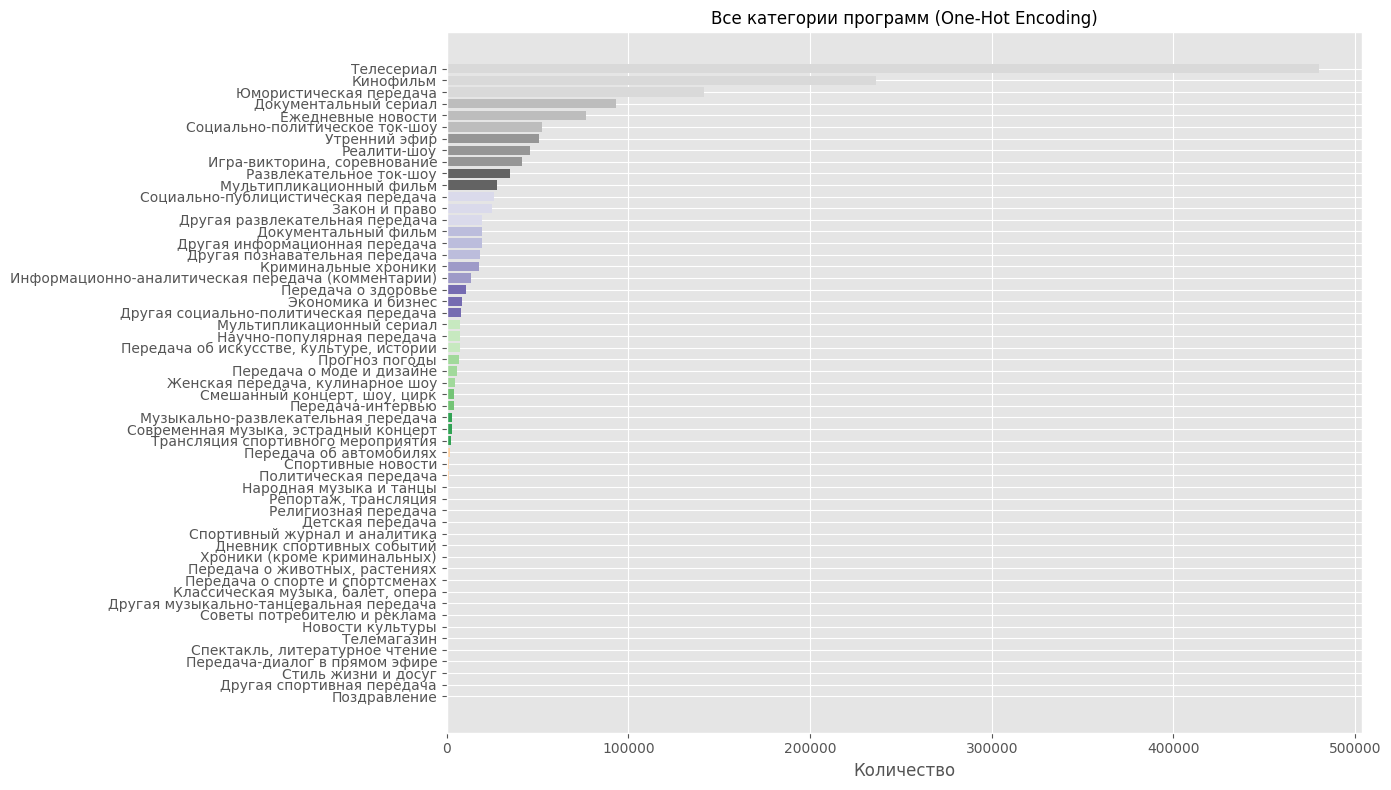

In [ ]:
# 6. Все категории программ (One-Hot)
plt.figure(figsize=(14, 8))
cat_cols = [col for col in data_encoded.columns if 'programCategoryName_' in col]
cat_counts = data_encoded[cat_cols].sum().sort_values()
plt.barh([x.replace('programCategoryName_', '') for x in cat_counts.index], cat_counts,
         color=plt.cm.tab20c(np.linspace(0, 1, len(cat_counts))))
plt.title('Все категории программ (One-Hot Encoding)', fontsize=12)
plt.xlabel('Количество')

plt.tight_layout()
plt.show()